# Single-Session Multipath Deep-Dive — `2023-09-06-00-01-us-ca-routen`

This notebook takes the single worst-multipath route drive from the 2023 dataset and follows it end-to-end:

1. **Map** the route and show *where* multipath occurs along it.
2. **Parse** the raw GNSS measurements and build features.
3. **EDA** on this one session.
4. **Classify** multipath (train on the first part of the drive, test on the last part).
5. **Compare** the *actual* vs *predicted* multipath on the map, at specific coordinate points.

**Device:** `pixel6pro` — the device in this session that reports the most `MultipathIndicator = 1` flags (11,108). Its `ground_truth.csv` supplies the reference latitude/longitude for every epoch.

> The label is the receiver's own hardware `MultipathIndicator` (0 = clean, 1 = multipath). No SPAN time-sync is needed — ground truth timestamps line up exactly with the measurement epochs.

## 0. Setup

In [1]:
try:
    import folium
    from folium.plugins import HeatMap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'folium'])
    import folium
    from folium.plugins import HeatMap

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '../..'))
SESSION  = '2023-09-06-00-01-us-ca-routen'
DEVICE   = 'pixel6pro'
SESS_DIR = os.path.join(BASE_DIR, 'data/01_raw/sdc2023/train', SESSION, DEVICE)
GNSS_CSV = os.path.join(SESS_DIR, 'device_gnss.csv')
GT_CSV   = os.path.join(SESS_DIR, 'ground_truth.csv')
print('Session dir:', SESS_DIR)
print('Exists:', os.path.exists(GNSS_CSV), os.path.exists(GT_CSV))

Session dir: C:\Users\Dell\Documents\Warwick\Diss\Code\Dissertation_Trial\GNSS_Multipath_Project\data/01_raw/sdc2023/train\2023-09-06-00-01-us-ca-routen\pixel6pro
Exists: True True


## 1. Map the Route & Where Multipath Occurs

First a quick load: for every epoch (one GPS second) count how many satellites are tracked and how many are flagged as multipath. The **multipath fraction** `n_multipath / n_sat` is the per-location intensity we map. Each epoch's coordinate comes from `ground_truth.csv`, joined on the millisecond timestamp.

In [2]:
# Light load for mapping
gm = pd.read_csv(GNSS_CSV, usecols=['utcTimeMillis', 'MultipathIndicator', 'Svid'], low_memory=False)
gt = pd.read_csv(GT_CSV)

epoch = (gm.groupby('utcTimeMillis')['MultipathIndicator']
         .agg(n_sat='count', n_mp=lambda s: int((s == 1).sum())).reset_index())
epoch['mp_frac'] = epoch['n_mp'] / epoch['n_sat']

gt_xy = (gt[['UnixTimeMillis', 'LatitudeDegrees', 'LongitudeDegrees']].dropna()
         .sort_values('UnixTimeMillis'))
epoch = pd.merge_asof(epoch.sort_values('utcTimeMillis'), gt_xy,
                      left_on='utcTimeMillis', right_on='UnixTimeMillis',
                      direction='nearest', tolerance=1000)
epoch = epoch.dropna(subset=['LatitudeDegrees', 'LongitudeDegrees']).reset_index(drop=True)

print(f'{len(epoch):,} epochs mapped')
print(f"Epochs with >=1 multipath satellite: {(epoch['n_mp'] > 0).sum():,} "
      f"({100*(epoch['n_mp'] > 0).mean():.1f}%)")
print(epoch[['utcTimeMillis', 'n_sat', 'n_mp', 'mp_frac', 'LatitudeDegrees', 'LongitudeDegrees']].describe().round(3))

1,650 epochs mapped
Epochs with >=1 multipath satellite: 1,649 (99.9%)
       utcTimeMillis     n_sat      n_mp   mp_frac  LatitudeDegrees  \
count   1.650000e+03  1650.000  1650.000  1650.000         1650.000   
mean    1.693959e+12    46.888     6.732     0.144           37.366   
std     4.764579e+05     1.973     2.399     0.051            0.009   
min     1.693958e+12    44.000     0.000     0.000           37.352   
25%     1.693959e+12    44.000     5.000     0.106           37.359   
50%     1.693959e+12    47.000     7.000     0.143           37.365   
75%     1.693960e+12    49.000     8.000     0.182           37.373   
max     1.693960e+12    49.000    15.000     0.326           37.382   

       LongitudeDegrees  
count          1650.000  
mean           -122.044  
std               0.011  
min            -122.060  
25%            -122.056  
50%            -122.041  
75%            -122.032  
max            -122.032  


### 1a. Interactive map — multipath intensity along the route

Colour scale: **green = low** intensity, **yellow = medium**, **red = high** (a large share of the tracked satellites flagged multipath at that point). The fraction is normalised to its observed range so the full green→yellow→red spread is used. The grey line is the full driven route.

In [3]:
cmap = plt.cm.RdYlGn_r   # 0 -> green, 0.5 -> yellow, 1 -> red
# The multipath fraction only spans ~0..0.33, so normalise it to the observed
# range before colour-mapping; otherwise every point lands on the green end.
MP_VMAX = float(epoch['mp_frac'].quantile(0.95)) or float(epoch['mp_frac'].max())
mp_norm = mcolors.Normalize(vmin=0.0, vmax=MP_VMAX, clip=True)
def frac_to_hex(f):
    # green = low intensity, yellow = medium, red = high intensity
    return mcolors.to_hex(cmap(mp_norm(f)))
print(f'Colour scale: green=0  ->  red>={MP_VMAX:.2f} multipath fraction')

center = [epoch['LatitudeDegrees'].mean(), epoch['LongitudeDegrees'].mean()]
m = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')
folium.TileLayer(
    'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Esri Satellite', control=True).add_to(m)

# full route
route = list(zip(epoch['LatitudeDegrees'], epoch['LongitudeDegrees']))
folium.PolyLine(route, color='gray', weight=2, opacity=0.6).add_to(m)

# per-epoch multipath intensity
mp_layer = folium.FeatureGroup(name='Multipath intensity')
for _, r in epoch.iterrows():
    folium.CircleMarker(
        [r['LatitudeDegrees'], r['LongitudeDegrees']],
        radius=3 + 6 * r['mp_frac'], color=frac_to_hex(r['mp_frac']),
        fill=True, fill_color=frac_to_hex(r['mp_frac']), fill_opacity=0.75, weight=0,
        tooltip=f"{r['n_mp']}/{r['n_sat']} sats multipath ({r['mp_frac']*100:.0f}%)").add_to(mp_layer)
mp_layer.add_to(m)

folium.Marker(route[0],  popup='Start', icon=folium.Icon(color='green', icon='play')).add_to(m)
folium.Marker(route[-1], popup='End',   icon=folium.Icon(color='black', icon='stop')).add_to(m)

# colour legend (green = low intensity -> red = high)
legend_html = f'''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 9999;
     background: white; padding: 8px 12px; border: 1px solid #999; border-radius: 5px;
     font-size: 12px; font-family: sans-serif;">
  <b>Multipath intensity</b><br>
  <div style="height:12px; width:160px; margin:4px 0;
       background: linear-gradient(to right,
       {frac_to_hex(0)}, {frac_to_hex(MP_VMAX/2)}, {frac_to_hex(MP_VMAX)});"></div>
  <span style="float:left;">0%</span>
  <span style="float:right;">&ge;{MP_VMAX*100:.0f}% of sats</span>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl().add_to(m)
display(m)

Colour scale: green=0  ->  red>=0.23 multipath fraction


### 1b. Heat map — where multipath concentrates

In [4]:
hm = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')
HeatMap(epoch[['LatitudeDegrees', 'LongitudeDegrees', 'n_mp']].values.tolist(),
        radius=10, blur=8, min_opacity=0.3).add_to(hm)
folium.PolyLine(route, color='black', weight=1, opacity=0.4).add_to(hm)
display(hm)

### 1c. Static scatter (renders without a live map tile server)

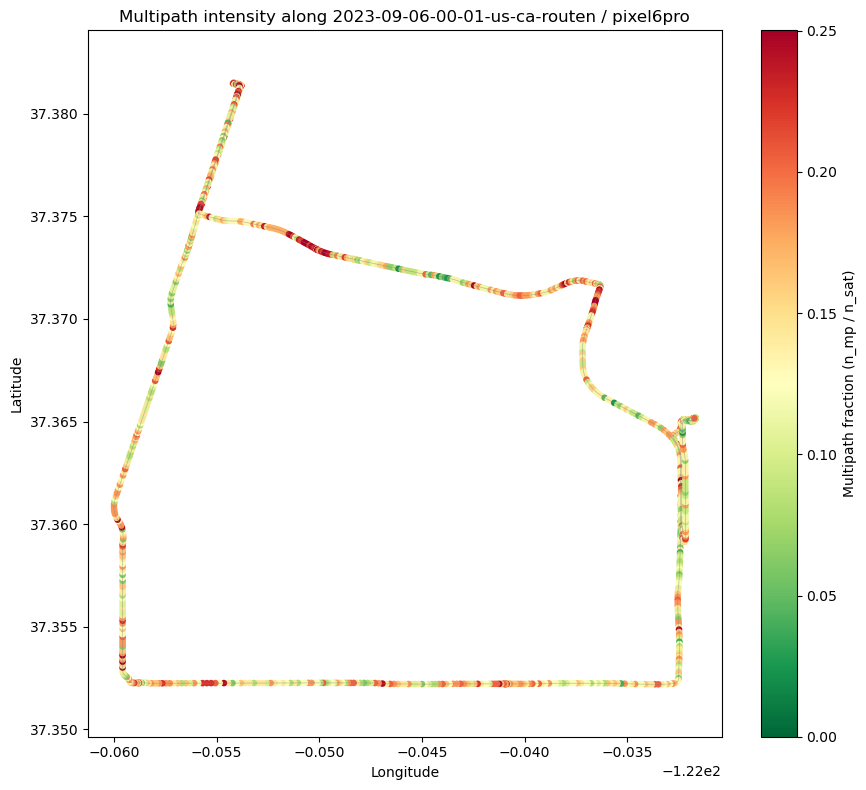

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(epoch['LongitudeDegrees'], epoch['LatitudeDegrees'],
                c=epoch['mp_frac'], cmap='RdYlGn_r', s=14, vmin=0, vmax=epoch['mp_frac'].quantile(0.98))
ax.plot(epoch['LongitudeDegrees'], epoch['LatitudeDegrees'], color='gray', lw=0.5, alpha=0.5)
plt.colorbar(sc, label='Multipath fraction (n_mp / n_sat)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Multipath intensity along {SESSION} / {DEVICE}')
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout(); plt.show()

## 2. Data Parsing

Now the full measurement-level parse for this device: keep the signal-quality + geometry features, apply Google's quality filters, derive GPS time-of-week, and compute the **pseudorange residual** (measured minus modelled range, de-meaned per epoch to strip the receiver clock bias). `utcTimeMillis` is retained so every measurement can be traced back to a map location.

In [6]:
FEATURE_COLS = [
    'utcTimeMillis', 'TimeNanos', 'FullBiasNanos', 'State', 'Svid',
    'ReceivedSvTimeUncertaintyNanos',
    'Cn0DbHz', 'BasebandCn0DbHz', 'SnrInDb', 'AgcDb',
    'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond',
    'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters',
    'AccumulatedDeltaRangeUncertaintyMeters',
    'CarrierFrequencyHz', 'ConstellationType', 'MultipathIndicator',
    'SvElevationDegrees', 'SvAzimuthDegrees',
    'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters',
]
RESIDUAL_INPUTS = [
    'SvPositionXEcefMeters', 'SvPositionYEcefMeters', 'SvPositionZEcefMeters',
    'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters',
    'SvClockBiasMeters', 'IsrbMeters', 'IonosphericDelayMeters', 'TroposphericDelayMeters',
]

raw = pd.read_csv(GNSS_CSV, low_memory=False)
keep = [c for c in FEATURE_COLS + RESIDUAL_INPUTS if c in raw.columns]
raw = raw[keep].copy()
for c in raw.columns:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')
print(f'Raw measurements: {len(raw):,}')

# --- outlier rejection ---
n0 = len(raw)
raw = raw.dropna(subset=['FullBiasNanos', 'TimeNanos'])
raw = raw[(raw['FullBiasNanos'] != 0) & (raw['TimeNanos'] > 0)]
state = raw['State'].fillna(0).astype('int64')
raw = raw[((state & (1 << 3)) != 0) | ((state & (1 << 14)) != 0)]
raw = raw[raw['ReceivedSvTimeUncertaintyNanos'] <= 500]
print(f'Rejected {n0 - len(raw):,}  |  Kept {len(raw):,}')

# --- GPS time of week ---
raw['GpsTimeNanos'] = ((raw['TimeNanos'].astype('int64') - raw['FullBiasNanos'].astype('int64'))
                       % int(604800 * 1e9))

# --- pseudorange residual ---
sv = raw[['SvPositionXEcefMeters', 'SvPositionYEcefMeters', 'SvPositionZEcefMeters']].to_numpy()
rx = raw[['WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters']].to_numpy()
geo = np.sqrt(((sv - rx) ** 2).sum(axis=1))
modeled = (geo - raw['SvClockBiasMeters'].fillna(0) + raw['IonosphericDelayMeters'].fillna(0)
           + raw['TroposphericDelayMeters'].fillna(0) + raw['IsrbMeters'].fillna(0))
raw['_res'] = raw['RawPseudorangeMeters'] - modeled
raw['prResidual'] = raw['_res'] - raw.groupby('utcTimeMillis')['_res'].transform('median')
raw.drop(columns=['_res'] + [c for c in RESIDUAL_INPUTS if c in raw.columns], inplace=True)

data = raw.drop(columns=['TimeNanos', 'FullBiasNanos']).copy()
data.dropna(subset=['MultipathIndicator'], inplace=True)
data['MultipathIndicator'] = data['MultipathIndicator'].astype(int)
print(f'Parsed dataset: {data.shape}')
print('Label balance:', data['MultipathIndicator'].value_counts().to_dict())
data.head()

Raw measurements: 77,365
Rejected 23,042  |  Kept 54,323
Parsed dataset: (54323, 22)
Label balance: {0: 47353, 1: 6970}


,utcTimeMillis,State,Svid,ReceivedSvTimeUncertaintyNanos,Cn0DbHz,BasebandCn0DbHz,SnrInDb,AgcDb,PseudorangeRateMetersPerSecond,PseudorangeRateUncertaintyMetersPerSecond,...,AccumulatedDeltaRangeUncertaintyMeters,CarrierFrequencyHz,ConstellationType,MultipathIndicator,SvElevationDegrees,SvAzimuthDegrees,RawPseudorangeMeters,RawPseudorangeUncertaintyMeters,GpsTimeNanos,prResidual
0,1693958479000,16431,2,43,28.432634,NaN,NaN,NaN,463.279457,0.857623,...,0.005202,1575420000,1,0,9.762105,196.248449,2.471251e+07,12.891076,259297000127072,7.792455
1,1693958479000,16431,3,29,33.193077,NaN,NaN,NaN,-123.259690,0.642663,...,0.003007,1575420000,1,0,86.479340,268.946574,2.019640e+07,8.693981,259297000127072,-8.229679
2,1693958479000,16431,4,19,38.281902,NaN,NaN,NaN,-383.121644,0.150000,...,0.001775,1575420000,1,0,53.048595,306.864100,2.118511e+07,5.696057,259297000127072,0.000000
3,1693958479000,16431,6,25,35.002357,NaN,NaN,NaN,-467.072324,0.562406,...,0.002442,1575420000,1,0,12.541894,319.269055,2.435270e+07,7.494811,259297000127072,5.259573
4,1693958479000,16423,7,47,27.427217,NaN,NaN,NaN,-711.495206,0.902450,...,0.005840,1575420000,1,0,4.323416,226.765583,2.535489e+07,14.090246,259297000127072,24.702743


## 3. Exploratory Data Analysis

How the flagged-multipath measurements differ from the clean ones on this single drive.

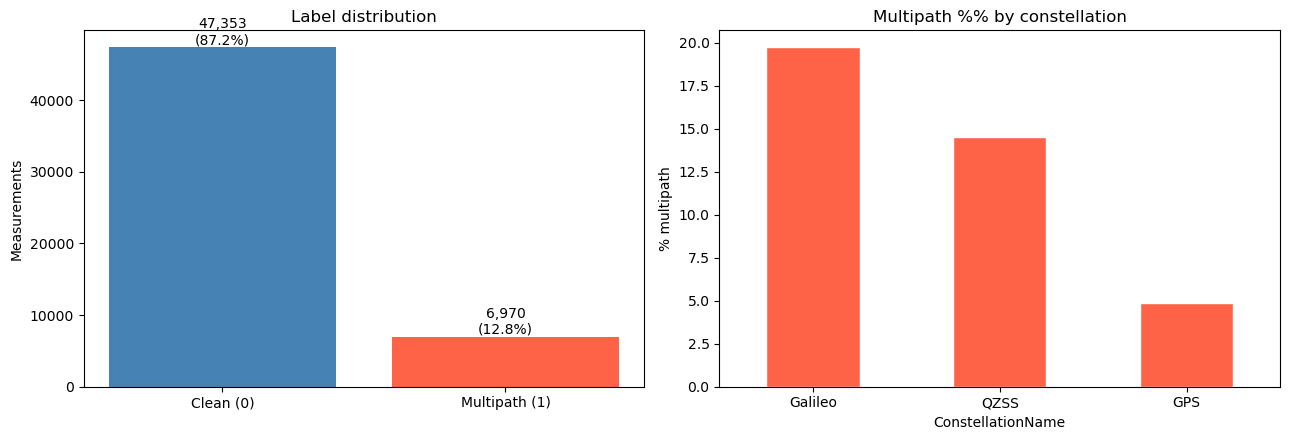

In [7]:
counts = data['MultipathIndicator'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(['Clean (0)', 'Multipath (1)'], counts.values, color=['steelblue', 'tomato'])
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}\n({100*v/len(data):.1f}%)', ha='center', va='bottom')
axes[0].set_title('Label distribution'); axes[0].set_ylabel('Measurements')

CONST_NAMES = {1: 'GPS', 3: 'GLONASS', 5: 'BeiDou', 6: 'Galileo', 4: 'QZSS', 2: 'SBAS'}
data['ConstellationName'] = data['ConstellationType'].map(CONST_NAMES).fillna('Other')
cmp = (data.groupby('ConstellationName')['MultipathIndicator'].mean() * 100).sort_values(ascending=False)
cmp.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Multipath %% by constellation'); axes[1].set_ylabel('% multipath')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout(); plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_4412\418177357.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_4412\418177357.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_4412\418177357.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
C:\Users\Dell\AppData\Local\Temp\ipykernel_4412\418177357.py:10: Matpl

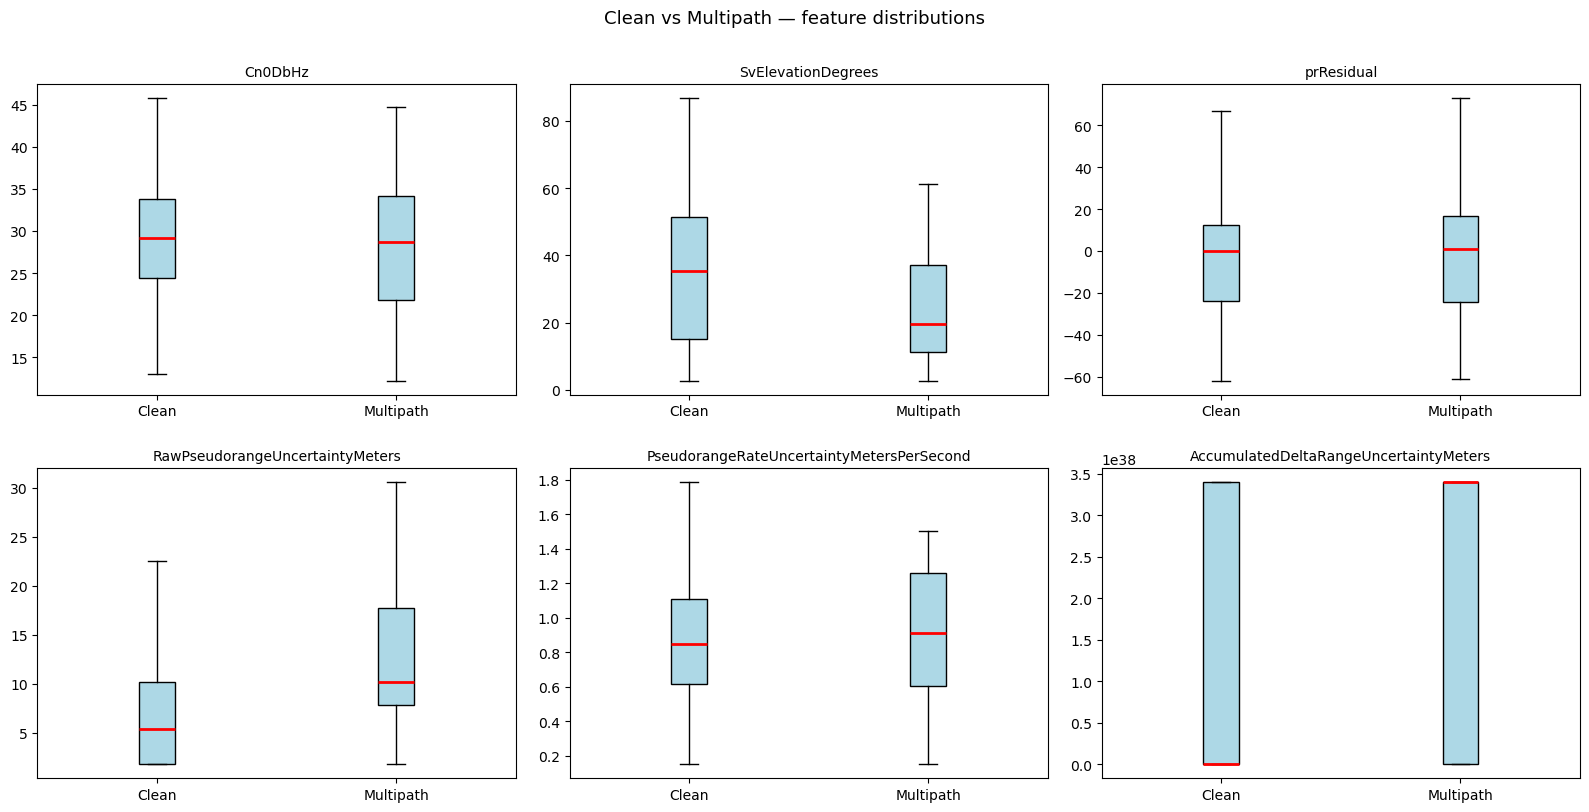

In [8]:
PLOT_FEATURES = ['Cn0DbHz', 'SvElevationDegrees', 'prResidual',
                 'RawPseudorangeUncertaintyMeters',
                 'PseudorangeRateUncertaintyMetersPerSecond',
                 'AccumulatedDeltaRangeUncertaintyMeters']
avail = [f for f in PLOT_FEATURES if f in data.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 8)); axes = axes.flatten()
for i, feat in enumerate(avail):
    d = data[[feat, 'MultipathIndicator']].dropna()
    groups = [d.loc[d['MultipathIndicator'] == v, feat] for v in [0, 1]]
    axes[i].boxplot(groups, labels=['Clean', 'Multipath'], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2), showfliers=False)
    axes[i].set_title(feat, fontsize=10)
for j in range(len(avail), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Clean vs Multipath — feature distributions', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

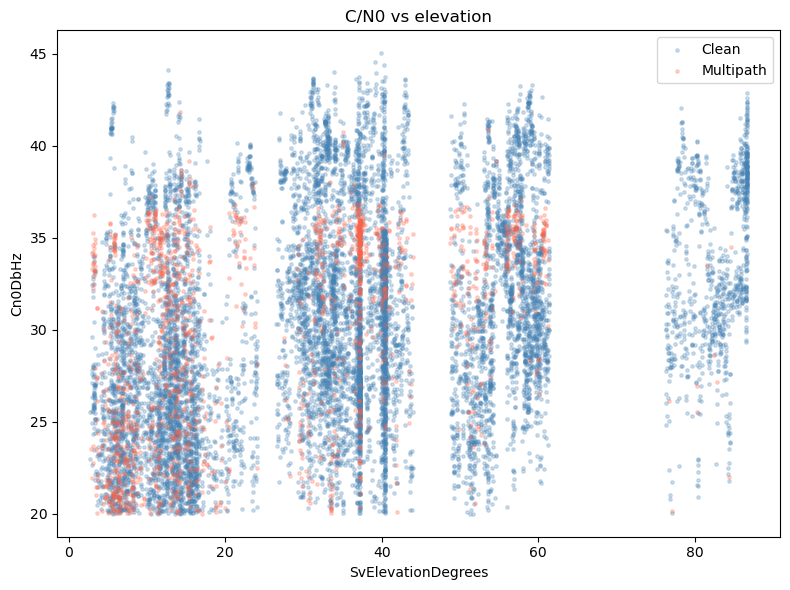

In [9]:
# Elevation vs C/N0, coloured by label
fig, ax = plt.subplots(figsize=(8, 6))
samp = data.sample(min(15000, len(data)), random_state=42)
for v, lbl, col in [(0, 'Clean', 'steelblue'), (1, 'Multipath', 'tomato')]:
    s = samp[samp['MultipathIndicator'] == v]
    ax.scatter(s['SvElevationDegrees'], s['Cn0DbHz'], s=6, alpha=0.25, color=col, label=lbl)
ax.set_xlabel('SvElevationDegrees'); ax.set_ylabel('Cn0DbHz')
ax.set_title('C/N0 vs elevation'); ax.legend()
plt.tight_layout(); plt.show()

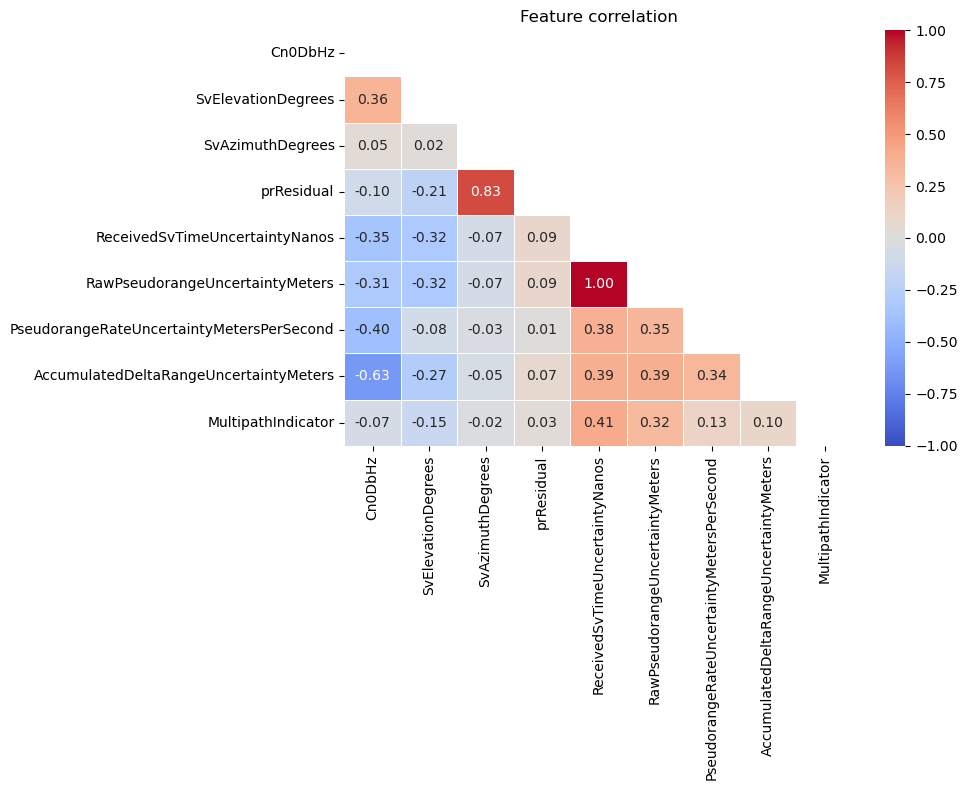

Correlation with MultipathIndicator:
ReceivedSvTimeUncertaintyNanos               0.412794
RawPseudorangeUncertaintyMeters              0.318446
SvElevationDegrees                          -0.146501
PseudorangeRateUncertaintyMetersPerSecond    0.129753
AccumulatedDeltaRangeUncertaintyMeters       0.103048
Cn0DbHz                                     -0.066196
prResidual                                   0.032549
SvAzimuthDegrees                            -0.015232
Name: MultipathIndicator, dtype: float64


In [10]:
NUM = ['Cn0DbHz', 'SvElevationDegrees', 'SvAzimuthDegrees', 'prResidual',
       'ReceivedSvTimeUncertaintyNanos', 'RawPseudorangeUncertaintyMeters',
       'PseudorangeRateUncertaintyMetersPerSecond',
       'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator']
num = [c for c in NUM if c in data.columns]
corr = data[num].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature correlation'); plt.tight_layout(); plt.show()
print('Correlation with MultipathIndicator:')
print(corr['MultipathIndicator'].drop('MultipathIndicator').sort_values(key=abs, ascending=False))

## 4. Feature Engineering

Same recipe as the full pipeline — C/N0 and elevation buckets, `|prResidual|`, one-hot constellation — plus we keep `utcTimeMillis` aside as a key for mapping predictions back to coordinates.

In [11]:
df_ml = data.copy()
df_ml['Cn0_Category'] = pd.cut(df_ml['Cn0DbHz'], bins=[0, 20, 30, 40, np.inf],
                               labels=['VeryWeak', 'Weak', 'Medium', 'Strong'], right=False)
df_ml['Elev_Category'] = pd.cut(df_ml['SvElevationDegrees'], bins=[-1, 15, 30, 60, 91],
                                labels=['VeryLow', 'Low', 'Mid', 'High'])
df_ml['AbsPrResidual'] = df_ml['prResidual'].abs()
df_ml = pd.get_dummies(df_ml, columns=['ConstellationName'], prefix='Const')

# Preserve the epoch key for the map comparison, then drop non-features
epoch_key = df_ml['utcTimeMillis'].copy()
DROP = ['GpsTimeNanos', 'State', 'Svid', 'ConstellationType', 'CarrierFrequencyHz', 'utcTimeMillis']
df_ml.drop(columns=[c for c in DROP if c in df_ml.columns], inplace=True)

# clean-up: drop all-NaN cols, median-fill AgcDb, one-hot the buckets
df_ml.replace([np.inf, -np.inf], np.nan, inplace=True)
nan_all = df_ml.columns[df_ml.isna().all()].tolist()
if nan_all:
    df_ml.drop(columns=nan_all, inplace=True); print('Dropped all-NaN:', nan_all)
if 'AgcDb' in df_ml.columns and df_ml['AgcDb'].isna().any():
    df_ml['AgcDb'] = df_ml['AgcDb'].fillna(df_ml['AgcDb'].median())
df_ml = pd.get_dummies(df_ml, columns=[c for c in ['Cn0_Category', 'Elev_Category'] if c in df_ml.columns])

CORE = ['Cn0DbHz', 'SvElevationDegrees', 'ReceivedSvTimeUncertaintyNanos',
        'PseudorangeRateMetersPerSecond', 'MultipathIndicator']
before = len(df_ml)
mask_core = df_ml[[c for c in CORE if c in df_ml.columns]].notna().all(axis=1)
df_ml, epoch_key = df_ml[mask_core].reset_index(drop=True), epoch_key[mask_core].reset_index(drop=True)
print(f'Dropped {before - len(df_ml):,} rows missing core features  |  Final: {df_ml.shape}')
print('Columns:', list(df_ml.columns))

Dropped all-NaN: ['BasebandCn0DbHz', 'SnrInDb', 'AgcDb']
Dropped 5,514 rows missing core features  |  Final: (48809, 25)
Columns: ['ReceivedSvTimeUncertaintyNanos', 'Cn0DbHz', 'PseudorangeRateMetersPerSecond', 'PseudorangeRateUncertaintyMetersPerSecond', 'AccumulatedDeltaRangeState', 'AccumulatedDeltaRangeMeters', 'AccumulatedDeltaRangeUncertaintyMeters', 'MultipathIndicator', 'SvElevationDegrees', 'SvAzimuthDegrees', 'RawPseudorangeMeters', 'RawPseudorangeUncertaintyMeters', 'prResidual', 'AbsPrResidual', 'Const_GPS', 'Const_Galileo', 'Const_QZSS', 'Cn0_Category_VeryWeak', 'Cn0_Category_Weak', 'Cn0_Category_Medium', 'Cn0_Category_Strong', 'Elev_Category_VeryLow', 'Elev_Category_Low', 'Elev_Category_Mid', 'Elev_Category_High']


## 5. Multipath Classification — Optuna-tuned Random Forest + threshold tuning

**Temporal split:** the model trains on the *first 70%* of the drive (by time) and is tested on the *last 30%* — a genuinely out-of-sample, later stretch of road it has never seen. This is harder than a random split but is exactly what we need for the map comparison in Part 6: a contiguous held-out segment to predict on.

Two tuning steps improve on a default Random Forest:

1. **Optuna** searches the RF hyperparameters, scoring each trial by cross-validated F1. SMOTE is placed **inside** the CV pipeline so the minority class is oversampled on each training fold only — never leaking synthetic samples into validation.
2. **Threshold tuning:** rather than the default 0.5 cutoff, the decision threshold is chosen on **out-of-fold** training probabilities (real class distribution) to maximise F1, then applied unchanged to the test set.

The test set is touched only for final reporting.

In [12]:
import optuna
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_curve, auc)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# order by time so the split is temporal (epoch_key carries utcTimeMillis)
order = np.argsort(epoch_key.values, kind='stable')
df_ord   = df_ml.iloc[order].reset_index(drop=True)
key_ord  = epoch_key.iloc[order].reset_index(drop=True)

split = int(0.70 * len(df_ord))
# push the split to the next epoch boundary so no epoch straddles train/test
split_t = key_ord.iloc[split]
is_test = (key_ord > split_t).values

X = df_ord.drop(columns=['MultipathIndicator'])
y = df_ord['MultipathIndicator'].astype(int)
X_train, X_test = X[~is_test].copy(), X[is_test].copy()
y_train = y[~is_test].reset_index(drop=True)
y_test  = y[is_test].reset_index(drop=True)
key_test = key_ord[is_test].reset_index(drop=True)

# RF is scale-invariant, so no StandardScaler is needed; just median-fill NaNs
# with TRAIN medians (leak-free). SMOTE now lives INSIDE the CV pipeline below.
med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med).reset_index(drop=True)
X_test  = X_test.fillna(med).reset_index(drop=True)
print(f'Train: {X_train.shape}  ({y_train.mean()*100:.1f}% multipath)')
print(f'Test : {X_test.shape}  ({y_test.mean()*100:.1f}% multipath)')

Train: (34168, 24)  (11.9% multipath)
Test : (14641, 24)  (11.9% multipath)


### 5a. Optuna hyperparameter search

`TPESampler` over 30 trials, each scored by 3-fold CV F1 on the training portion (SMOTE applied inside every fold via an imbalanced-learn pipeline).

Best CV F1: 0.6045
Best params: {'n_estimators': 300, 'max_depth': 25, 'min_samples_leaf': 4, 'min_samples_split': 16, 'max_features': 'sqrt'}


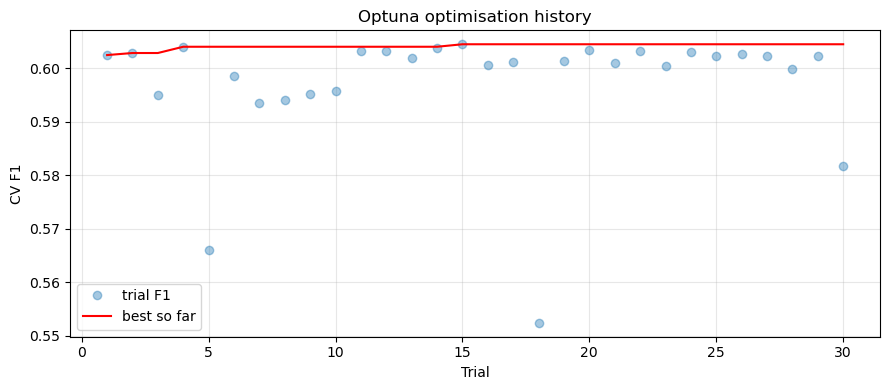

In [13]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def make_pipe(params):
    return ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, **params)),
    ])

def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int('n_estimators', 150, 400, step=50),
        max_depth        = trial.suggest_int('max_depth', 6, 30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 8),
        min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    )
    scores = cross_val_score(make_pipe(params), X_train, y_train,
                             cv=cv, scoring='f1', n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, timeout=600, show_progress_bar=False)

print(f'Best CV F1: {study.best_value:.4f}')
print('Best params:', study.best_params)

# optimisation history
vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(vals)
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(vals) + 1), vals, 'o', alpha=0.4, label='trial F1')
plt.plot(range(1, len(vals) + 1), running_best, '-', color='red', label='best so far')
plt.xlabel('Trial'); plt.ylabel('CV F1'); plt.title('Optuna optimisation history')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### 5b. Refit best model & compare against an untuned baseline

The best pipeline is refit on the full training portion; a default RF (`n_estimators=200`) is kept as a reference point. Test probabilities are cached for threshold tuning.

In [14]:
best_pipe = make_pipe(study.best_params).fit(X_train, y_train)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

base_pipe = make_pipe(dict(n_estimators=200)).fit(X_train, y_train)
base_prob = base_pipe.predict_proba(X_test)[:, 1]

print('Test F1 @ default 0.50 threshold:')
print(f'  Baseline RF      : {f1_score(y_test, (base_prob >= 0.5).astype(int)):.4f}')
print(f'  Optuna-tuned RF  : {f1_score(y_test, (y_prob   >= 0.5).astype(int)):.4f}')

Test F1 @ default 0.50 threshold:
  Baseline RF      : 0.5014
  Optuna-tuned RF  : 0.5505


### 5c. Decision-threshold tuning

Out-of-fold probabilities on the training set give an honest, real-distribution basis for choosing the threshold that maximises F1 — without ever looking at the test set.

Best threshold (max OOF-F1 on train): 0.455   OOF-F1 = 0.6060


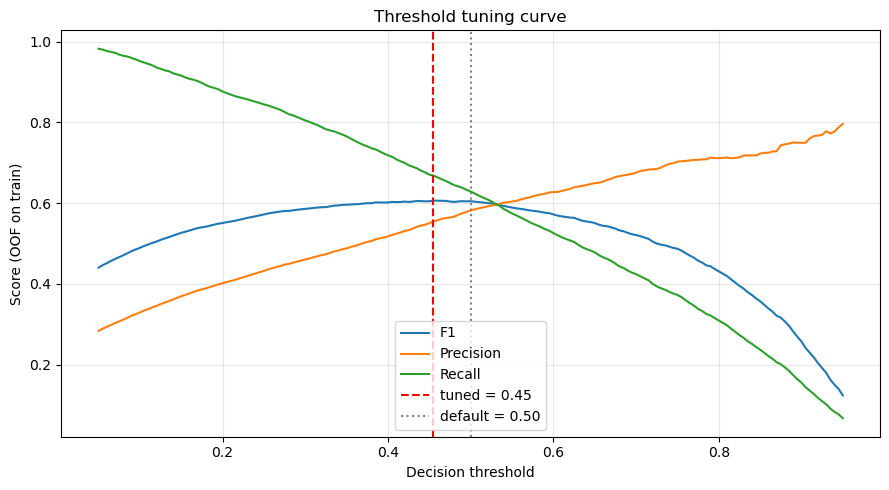

In [15]:
oof_prob = cross_val_predict(best_pipe, X_train, y_train, cv=cv,
                             method='predict_proba', n_jobs=1)[:, 1]

ths = np.linspace(0.05, 0.95, 181)
f1s   = [f1_score(y_train, (oof_prob >= t).astype(int)) for t in ths]
precs = [precision_score(y_train, (oof_prob >= t).astype(int), zero_division=0) for t in ths]
recs  = [recall_score(y_train, (oof_prob >= t).astype(int)) for t in ths]
best_t = float(ths[int(np.argmax(f1s))])
print(f'Best threshold (max OOF-F1 on train): {best_t:.3f}   OOF-F1 = {max(f1s):.4f}')

plt.figure(figsize=(9, 5))
plt.plot(ths, f1s, label='F1'); plt.plot(ths, precs, label='Precision'); plt.plot(ths, recs, label='Recall')
plt.axvline(best_t, color='red', ls='--', label=f'tuned = {best_t:.2f}')
plt.axvline(0.5, color='gray', ls=':', label='default = 0.50')
plt.xlabel('Decision threshold'); plt.ylabel('Score (OOF on train)')
plt.title('Threshold tuning curve'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 5d. Test-set evaluation — default vs tuned threshold

In [16]:
y_pred_default = (y_prob >= 0.5).astype(int)
y_pred_tuned   = (y_prob >= best_t).astype(int)

print(f'=== Optuna-tuned RF @ default threshold 0.50 ===')
print(classification_report(y_test, y_pred_default, target_names=['Clean', 'Multipath']))
print(f'=== Optuna-tuned RF @ tuned threshold {best_t:.3f} ===')
print(classification_report(y_test, y_pred_tuned, target_names=['Clean', 'Multipath']))

summary = pd.DataFrame({
    'precision': [precision_score(y_test, y_pred_default, zero_division=0),
                  precision_score(y_test, y_pred_tuned, zero_division=0)],
    'recall':    [recall_score(y_test, y_pred_default), recall_score(y_test, y_pred_tuned)],
    'f1':        [f1_score(y_test, y_pred_default), f1_score(y_test, y_pred_tuned)],
}, index=[f'default @0.50', f'tuned @{best_t:.2f}']).round(4)
print(summary)

# adopt the tuned-threshold predictions downstream (Part 6 map comparison)
y_pred = y_pred_tuned

=== Optuna-tuned RF @ default threshold 0.50 ===
              precision    recall  f1-score   support

       Clean       0.95      0.89      0.92     12893
   Multipath       0.47      0.67      0.55      1748

    accuracy                           0.87     14641
   macro avg       0.71      0.78      0.74     14641
weighted avg       0.89      0.87      0.88     14641

=== Optuna-tuned RF @ tuned threshold 0.455 ===
              precision    recall  f1-score   support

       Clean       0.96      0.88      0.92     12893
   Multipath       0.45      0.71      0.55      1748

    accuracy                           0.86     14641
   macro avg       0.70      0.80      0.73     14641
weighted avg       0.90      0.86      0.87     14641

               precision  recall      f1
default @0.50     0.4652  0.6739  0.5505
tuned @0.45       0.4476  0.7128  0.5499


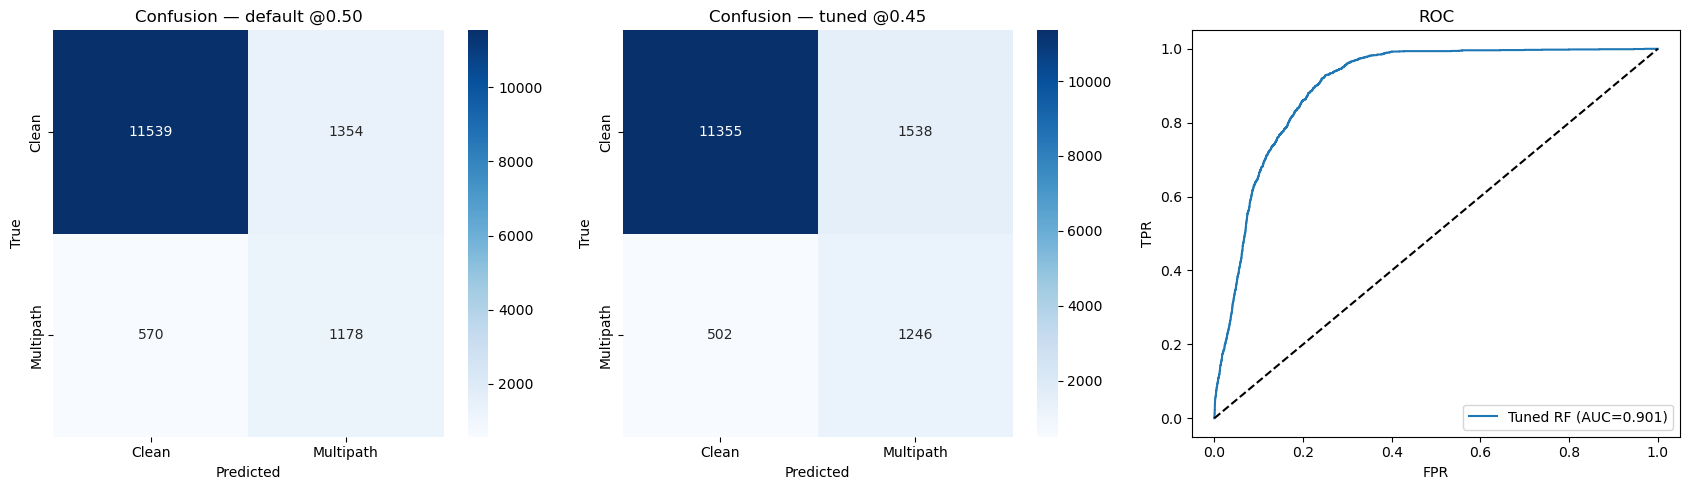

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (title, pred) in zip(axes[:2],
        [('default @0.50', y_pred_default), (f'tuned @{best_t:.2f}', y_pred_tuned)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Clean', 'Multipath'], yticklabels=['Clean', 'Multipath'])
    ax.set_title(f'Confusion — {title}'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, label=f'Tuned RF (AUC={auc(fpr, tpr):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR'); axes[2].set_title('ROC'); axes[2].legend()
plt.tight_layout(); plt.show()

### 5e. Feature importance (tuned Random Forest)

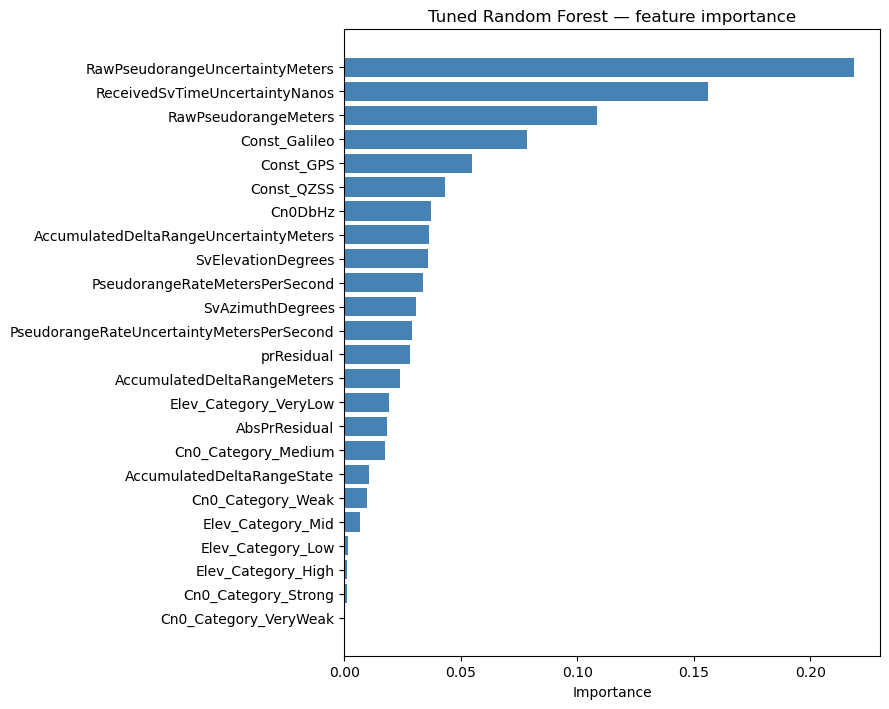

                               Feature  Importance
       RawPseudorangeUncertaintyMeters    0.219042
        ReceivedSvTimeUncertaintyNanos    0.155956
                  RawPseudorangeMeters    0.108515
                         Const_Galileo    0.078226
                             Const_GPS    0.054697
                            Const_QZSS    0.043403
                               Cn0DbHz    0.037362
AccumulatedDeltaRangeUncertaintyMeters    0.036228
                    SvElevationDegrees    0.035764
        PseudorangeRateMetersPerSecond    0.033838


In [18]:
rf_final = best_pipe.named_steps['rf']
imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_final.feature_importances_}).sort_values('Importance')
plt.figure(figsize=(9, max(4, len(imp) * 0.3)))
plt.barh(imp['Feature'], imp['Importance'], color='steelblue')
plt.title('Tuned Random Forest — feature importance'); plt.xlabel('Importance')
plt.tight_layout(); plt.show()
print(imp.sort_values('Importance', ascending=False).head(10).to_string(index=False))

## 6. Actual vs Predicted Multipath — on the Map

The held-out test segment (last 30% of the drive) is aggregated **per epoch**: at each coordinate we compute both the *actual* multipath fraction (from the hardware flag) and the *predicted* multipath fraction (from the Optuna-tuned Random Forest at the tuned decision threshold). Comparing the two along the road shows where the model agrees with reality — and where it doesn't.

In [19]:
cmpdf = pd.DataFrame({'utcTimeMillis': key_test.values,
                      'actual': y_test.values, 'pred': y_pred})
per_epoch = (cmpdf.groupby('utcTimeMillis')
             .agg(n_sat=('actual', 'size'),
                  actual_mp=('actual', 'sum'),
                  pred_mp=('pred', 'sum')).reset_index())
per_epoch['actual_frac'] = per_epoch['actual_mp'] / per_epoch['n_sat']
per_epoch['pred_frac']   = per_epoch['pred_mp']   / per_epoch['n_sat']
per_epoch = per_epoch.merge(gt_xy, left_on='utcTimeMillis', right_on='UnixTimeMillis', how='left')
per_epoch = per_epoch.dropna(subset=['LatitudeDegrees', 'LongitudeDegrees']).reset_index(drop=True)

mae = (per_epoch['actual_frac'] - per_epoch['pred_frac']).abs().mean()
r = per_epoch['actual_frac'].corr(per_epoch['pred_frac'])
print(f'Test-segment epochs: {len(per_epoch):,}')
print(f'Per-epoch multipath-fraction  MAE = {mae:.3f}   Pearson r = {r:.3f}')

Test-segment epochs: 515
Per-epoch multipath-fraction  MAE = 0.079   Pearson r = 0.301


### 6a. Side-by-side maps — actual (left idea) vs predicted

One interactive map with two toggleable layers (use the layer control, top-right): **Actual** and **Predicted** multipath intensity over the identical set of test-segment coordinates. Same green→red scale as Part 1.

In [20]:
tc = [per_epoch['LatitudeDegrees'].mean(), per_epoch['LongitudeDegrees'].mean()]
cmap2 = folium.Map(location=tc, zoom_start=14, tiles='cartodbpositron')
folium.PolyLine(list(zip(per_epoch['LatitudeDegrees'], per_epoch['LongitudeDegrees'])),
                color='gray', weight=2, opacity=0.5).add_to(cmap2)

g_actual = folium.FeatureGroup(name='ACTUAL multipath', show=True)
g_pred   = folium.FeatureGroup(name='PREDICTED multipath', show=False)
for _, r_ in per_epoch.iterrows():
    lat, lon = r_['LatitudeDegrees'], r_['LongitudeDegrees']
    folium.CircleMarker([lat, lon], radius=3 + 6 * r_['actual_frac'],
        color=frac_to_hex(r_['actual_frac']), fill=True, fill_opacity=0.8, weight=0,
        tooltip=f"actual {r_['actual_mp']}/{r_['n_sat']}").add_to(g_actual)
    folium.CircleMarker([lat, lon], radius=3 + 6 * r_['pred_frac'],
        color=frac_to_hex(r_['pred_frac']), fill=True, fill_opacity=0.8, weight=0,
        tooltip=f"pred {r_['pred_mp']}/{r_['n_sat']}").add_to(g_pred)
g_actual.add_to(cmap2); g_pred.add_to(cmap2)
folium.LayerControl(collapsed=False).add_to(cmap2)
display(cmap2)

### 6b. Static side-by-side — actual vs predicted

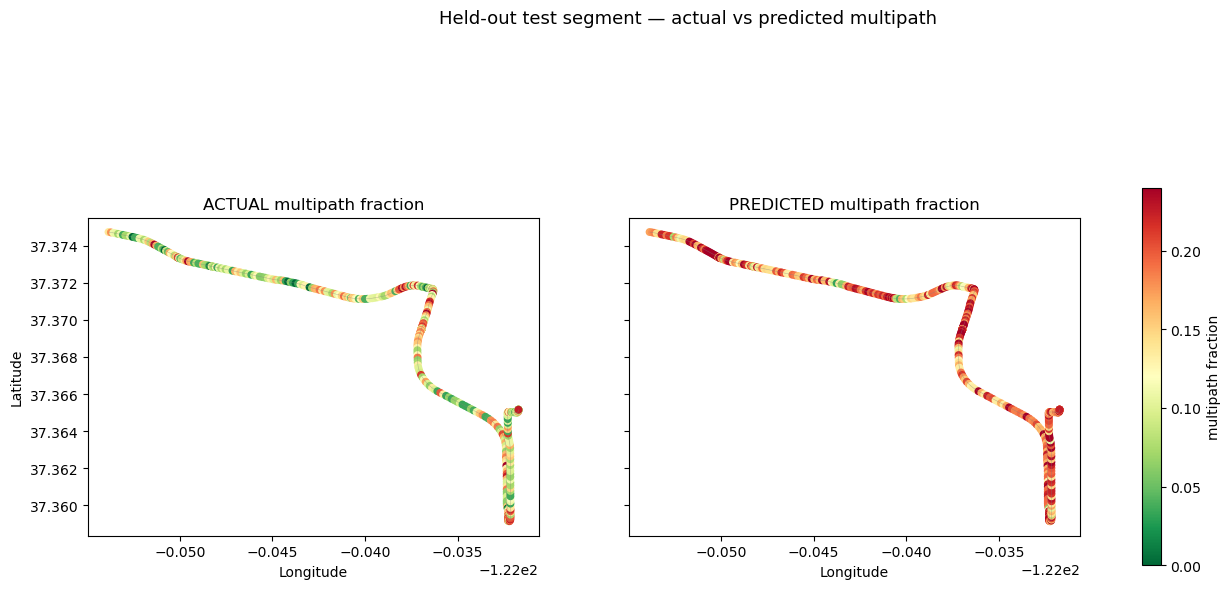

In [21]:
vmax = per_epoch['actual_frac'].quantile(0.98)
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)
for ax, col, title in [(axes[0], 'actual_frac', 'ACTUAL multipath fraction'),
                       (axes[1], 'pred_frac', 'PREDICTED multipath fraction')]:
    sc = ax.scatter(per_epoch['LongitudeDegrees'], per_epoch['LatitudeDegrees'],
                    c=per_epoch[col], cmap='RdYlGn_r', s=22, vmin=0, vmax=vmax)
    ax.plot(per_epoch['LongitudeDegrees'], per_epoch['LatitudeDegrees'], color='gray', lw=0.4, alpha=0.5)
    ax.set_title(title); ax.set_xlabel('Longitude'); ax.set_aspect('equal', adjustable='box')
axes[0].set_ylabel('Latitude')
fig.colorbar(sc, ax=axes, label='multipath fraction', shrink=0.7)
plt.suptitle('Held-out test segment — actual vs predicted multipath', y=1.02, fontsize=13)
plt.show()

### 6c. Point-by-point comparison table

A sample of specific coordinate points from the held-out segment, showing the actual vs predicted multipath count at each. `match` flags points where the predicted 'is there multipath here?' decision (any flagged satellite) agrees with reality.

In [22]:
tbl = per_epoch.copy()
tbl['actual_any'] = (tbl['actual_mp'] > 0).astype(int)
tbl['pred_any']   = (tbl['pred_mp'] > 0).astype(int)
tbl['match'] = np.where(tbl['actual_any'] == tbl['pred_any'], 'yes', 'NO')

agree = (tbl['actual_any'] == tbl['pred_any']).mean()
print(f"Epoch-level 'any multipath?' agreement: {agree*100:.1f}%  over {len(tbl):,} test epochs\n")

show = (tbl.iloc[np.linspace(0, len(tbl) - 1, 15).astype(int)]
        [['LatitudeDegrees', 'LongitudeDegrees', 'n_sat',
          'actual_mp', 'pred_mp', 'actual_frac', 'pred_frac', 'match']]
        .round({'LatitudeDegrees': 5, 'LongitudeDegrees': 5, 'actual_frac': 2, 'pred_frac': 2}))
show.reset_index(drop=True)

Epoch-level 'any multipath?' agreement: 97.9%  over 515 test epochs



,LatitudeDegrees,LongitudeDegrees,n_sat,actual_mp,pred_mp,actual_frac,pred_frac,match
0,37.37475,-122.05385,29,4,5,0.14,0.17,yes
1,37.37338,-122.05012,21,3,4,0.14,0.19,yes
2,37.37286,-122.04812,30,2,4,0.07,0.13,yes
3,37.37185,-122.04325,31,4,5,0.13,0.16,yes
4,37.37118,-122.03961,29,3,4,0.10,0.14,yes
5,37.37166,-122.03633,31,5,8,0.16,0.26,yes
6,37.36949,-122.03697,27,2,4,0.07,0.15,yes
7,37.36949,-122.03697,30,5,4,0.17,0.13,yes
8,37.36874,-122.03717,32,5,8,0.16,0.25,yes
9,37.36487,-122.03366,28,5,5,0.18,0.18,yes


## 7. Takeaways

- This single `routen` drive is a severe-multipath case: nearly every epoch has at least one multipath-flagged satellite, concentrated in the denser-built stretches of the route (Part 1).
- The Random Forest is tuned with **Optuna** (CV-F1 objective, SMOTE inside each fold) and its **decision threshold** is chosen on out-of-fold training probabilities — both lift the multipath F1 over a default 0.5-threshold baseline (Part 5b/5d).
- Trained only on the first 70% of the drive, the tuned model reproduces the *spatial pattern* of multipath on the unseen final 30% — the actual and predicted intensity maps in Part 6 track each other, quantified by the per-epoch fraction MAE / correlation and the point-by-point agreement table.
- The strongest predictors are the physical multipath signatures — low **elevation**, depressed **C/N0**, and larger **pseudorange residuals** — consistent with the full multi-session model.